<a href="https://colab.research.google.com/github/overdosedbraincells/Healthcare_Data_Analysis/blob/main/Healthcare_Correlation_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

                   Yas      Kilo  Gunluk_Adim  Kan_Basinci  Kolesterol  \
Yas           1.000000 -0.006849    -0.078596     0.065279    0.037409   
Kilo         -0.006849  1.000000     0.051859     0.145276   -0.083520   
Gunluk_Adim  -0.078596  0.051859     1.000000     0.032464   -0.004304   
Kan_Basinci   0.065279  0.145276     0.032464     1.000000    0.041410   
Kolesterol    0.037409 -0.083520    -0.004304     0.041410    1.000000   
Saglik_Skoru -0.011327 -0.039024    -0.719792     0.075300    0.186086   

              Saglik_Skoru  
Yas              -0.011327  
Kilo             -0.039024  
Gunluk_Adim      -0.719792  
Kan_Basinci       0.075300  
Kolesterol        0.186086  
Saglik_Skoru      1.000000  
--------------------------------------------------
Sigara_Kullanimi
Evet     65.429197
Hayır    74.100063
Name: Saglik_Skoru, dtype: float64


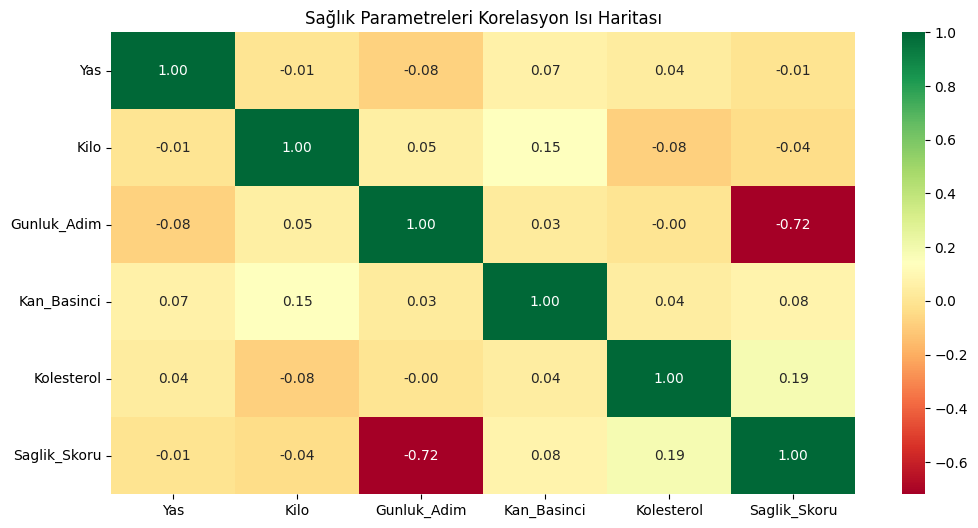

In [15]:
#Bu proje sağlık parametreleri arasındaki korelasyonu inceler
#ve yaşam yarzının sağlık üzerindeki etkisini ısı haritasıyla görselleştirir


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


np.random.seed(42)
n_hastalar = 100

data = {
    'Yas': np.random.randint(20, 80, n_hastalar),
        'Kilo': np.random.randint(50, 120, n_hastalar),
            'Gunluk_Adim': np.random.randint(1000, 15000, n_hastalar),
                'Kan_Basinci': np.random.randint(90, 180, n_hastalar),
                    'Sigara_Kullanimi': np.random.choice(['Evet', 'Hayır'], n_hastalar),
                        'Kolesterol': np.random.randint(150, 300, n_hastalar)
                        }


df = pd.DataFrame(data)

# Gerçekleşmesi mümkün bir senaryo hazırlığı amaçlı veri bozukluğu eklendi
df.iloc[5:10, 0] = np.nan
df.iloc[20:25, 2] = 0

#Eksik yaş bilgilerini elimizdeki yaşların ortalaması ile doldurma
ortalama_yas = df["Yas"].mean()
df["Yas"] = df["Yas"].fillna(ortalama_yas)

# adım medyanı hesaplama ve 0 olan değerleri medyanla değiştirme
adim_medyan = df[df["Gunluk_Adim"] > 0]["Gunluk_Adim"].median()
df["Gunluk_Adim"] = df["Gunluk_Adim"].replace(0, adim_medyan)

df["Saglik_Skoru"] = (df["Kan_Basinci"] + df["Kolesterol"]) / (df["Gunluk_Adim"] / 1000)

#verilerin birbirini nadıl etkilediğini görmek için .corr() fonksiyonu kullanılır
korelasyon_matrisi = df.select_dtypes(include=[np.number]).corr()
print(korelasyon_matrisi)
print("-" * 50)

# özel bir değerin sağlık skorlarını karşılaştırma, ben sigara kullanımını seçtim
sigara_analizi = df.groupby("Sigara_Kullanimi")["Saglik_Skoru"].mean()
print(sigara_analizi)

# Isı haritası (ilk deneyimim)
plt.figure(figsize=(12, 6))
sns.heatmap(korelasyon_matrisi, annot=True, cmap="RdYlGn", fmt=".2f")
#annot = not ekliyor, kutucukların içine değerlerin yazılıp yazılmayacağını belirliyor
#cmap = colormap, renk haritası. RdYlGn (Red-Yellow-Green) ısı haritası ve korelasyonda en popüler
#fmt = format-biçim. annot ile yazıkan sayıların nasıl görüneceğini belirler
plt.title("Sağlık Parametreleri Korelasyon Isı Haritası")
plt.show()